# Assemble the GSE292189 Bianchi validation cohort

**Biology rationale.** A second independent dataset broadens validation of plasma-cell and microenvironment findings.

**Aim.** Construct a harmonized Seurat object from public matrices and metadata, including BRI annotations.

**Data input.** `GSE292189_CD138+_barcodes_and_metadata.csv`, `GSE292189_CD138-_barcodes_and_metadata.csv`, `GSE292189_assembled_with_BRI_seurat.rds`, `GSE292189_cell_metadata_after_assembly_with_BRI.csv`, `QC_violin_by_CD138_fraction_with_BRI.pdf`



**Data outputs.** Processed objects, statistical summaries, and visualizations generated in the notebook.

## 1. Package setup


In [1]:
# ============================================================
# 0) Package setup
# ============================================================

suppressPackageStartupMessages({
  library(Seurat)
  library(Matrix)
  library(data.table)
  library(dplyr)
  library(tidyr)
  library(stringr)
  library(tibble)
  library(purrr)
  library(ggplot2)
  library(patchwork)
})

options(stringsAsFactors = FALSE)
set.seed(1234)

sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Rocky Linux 8.10 (Green Obsidian)

Matrix products: default
BLAS/LAPACK: /home/miniconda3/envs/jupyter/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8           LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/New_York
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2     ggplot2_3.5.2       purrr_1.1.0        
 [4] tibble_3.3.1        stringr_1.6.0       tidyr_1.3.2        
 [7] dplyr_1.1.4         data.table_1.18.2.1 Matrix_1.6-5       
[10] Seurat_5.1.0

In [2]:
# ============================================================
# 1) User settings and clean start
# ============================================================

# Put the three GEO files in this directory.
work_dir <- "."

raw_tar <- file.path(work_dir, "GSE292189_RAW.tar")

meta_files <- c(
  CD138_pos = file.path(work_dir, "GSE292189_CD138+_barcodes_and_metadata.csv.gz"),
  CD138_neg = file.path(work_dir, "GSE292189_CD138-_barcodes_and_metadata.csv.gz")
)

# If you have unzipped CSV metadata instead of .csv.gz, this fallback uses them.
if (!file.exists(meta_files[["CD138_pos"]]) &&
    file.exists(file.path(work_dir, "GSE292189_CD138+_barcodes_and_metadata.csv"))) {
  meta_files[["CD138_pos"]] <- file.path(work_dir, "GSE292189_CD138+_barcodes_and_metadata.csv")
}
if (!file.exists(meta_files[["CD138_neg"]]) &&
    file.exists(file.path(work_dir, "GSE292189_CD138-_barcodes_and_metadata.csv"))) {
  meta_files[["CD138_neg"]] <- file.path(work_dir, "GSE292189_CD138-_barcodes_and_metadata.csv")
}

out_dir <- file.path(work_dir, "GSE292189_Seurat_assembly")
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

extract_dir <- file.path(out_dir, "RAW_extracted")
dir.create(extract_dir, showWarnings = FALSE, recursive = TRUE)

# Keep permissive for assembly.
min.cells <- 3
min.features <- 200

# Final outputs.
out_rds <- file.path(out_dir, "GSE292189_assembled_with_BRI_seurat.rds")
out_meta_csv <- file.path(out_dir, "GSE292189_cell_metadata_after_assembly_with_BRI.csv.gz")

stopifnot(file.exists(raw_tar))
stopifnot(all(file.exists(meta_files)))

# Clean old objects if this notebook is rerun in the same R session.
for (x in c("obj", "objs", "count_mats", "joined", "meta_all")) {
  if (exists(x, inherits = FALSE)) rm(list = x)
}
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,3330164,177.9,5367850,286.7,5367850,286.7
Vcells,5820667,44.5,12255594,93.6,9904824,75.6


In [3]:
# ============================================================
# 2) Unpack RAW archive
# ============================================================

if (length(list.files(extract_dir, recursive = TRUE, all.files = FALSE)) == 0) {
  message("Extracting RAW tar archive...")
  untar(raw_tar, exdir = extract_dir)
} else {
  message("Extraction directory is not empty; skipping untar.")
}

raw_files <- list.files(extract_dir, recursive = TRUE, full.names = TRUE)
message("Number of extracted files: ", length(raw_files))
print(head(raw_files, 80))

Extraction directory is not empty; skipping untar.

Number of extracted files: 52



 [1] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852196_HDneg_gex_raw_counts.tsv.gz"     
 [2] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852197_HDneg_tcr_tcr_chains.airr.txt.gz"
 [3] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz"
 [4] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852199_ALneg_gex_raw_counts.tsv.gz"     
 [5] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852200_ALneg_tcr_tcr_chains.airr.txt.gz"
 [6] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz"
 [7] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852202_HDpos_gex_raw_counts.tsv.gz"     
 [8] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852203_HDpos_bcr_bcr_chains.airr.txt.gz"
 [9] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852204_ALpos_gex_raw_counts.tsv.gz"     
[10] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852205_ALpos_bcr_bcr_chains.airr.txt.gz"
[11] "./GSE292189_Seurat_assembly/RAW_extracted/GSM8852206_BRI-2044_ra

In [4]:
# ============================================================
# 3) Helper functions
# ============================================================


# Convert metadata library_name to raw count sample ID.
normalize_library_to_sample_id <- function(x) {
  x <- as.character(x)
  dplyr::case_when(
    x == "HDpos_gex" ~ "HDpos",
    x == "HDneg_gex" ~ "HDneg",
    x == "ALpos_gex" ~ "ALpos",
    x == "ALneg_gex" ~ "ALneg",
    TRUE ~ x
  )
}

# Extract sample prefix from a full cell ID when present.
get_sample_prefix <- function(cell_ids) {
  cell_ids <- as.character(cell_ids)
  dplyr::case_when(
    str_detect(cell_ids, "^HDpos-") ~ "HDpos",
    str_detect(cell_ids, "^HDneg-") ~ "HDneg",
    str_detect(cell_ids, "^ALpos-") ~ "ALpos",
    str_detect(cell_ids, "^ALneg-") ~ "ALneg",
    str_detect(cell_ids, "^BRI-[0-9]+-") ~ str_extract(cell_ids, "^BRI-[0-9]+"),
    TRUE ~ NA_character_
  )
}

# Remove exactly the sample prefix, not just text before first hyphen.
# This is crucial for BRI-2106 because the sample ID itself contains a hyphen.
# ============================================================
# Helper: get barcode core safely
# ============================================================

get_barcode_core <- function(cell_ids, sample_id = NULL) {
  cell_ids <- as.character(cell_ids)
  
  if (!is.null(sample_id)) {
    sample_id <- as.character(sample_id)
    
    out <- mapply(
      function(cid, sid) {
        if (is.na(cid) || is.na(sid) || sid == "") return(cid)
        
        prefix <- paste0(sid, "-")
        
        if (startsWith(cid, prefix)) {
          sub(prefix, "", cid, fixed = TRUE)
        } else {
          cid
        }
      },
      cell_ids,
      sample_id,
      USE.NAMES = FALSE
    )
    
  } else {
    out <- cell_ids
    
    out <- ifelse(startsWith(out, "HDpos-"), sub("HDpos-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "HDneg-"), sub("HDneg-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "ALpos-"), sub("ALpos-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "ALneg-"), sub("ALneg-", "", out, fixed = TRUE), out)
    
    bri_prefix <- str_extract(out, "^BRI-[0-9]+-")
    out <- ifelse(
      !is.na(bri_prefix),
      substring(out, nchar(bri_prefix) + 1),
      out
    )
  }
  
  # Remove 10x suffix only, e.g. AAAC...-1 -> AAAC...
  out <- str_replace(out, "-[0-9]+$", "")
  
  out
}
# Extract sample ID from raw count file name.
get_sample_id <- function(path) {
  x <- basename(path)
  x <- str_replace(x, "\\.tsv\\.gz$", "")
  x <- str_replace(x, "_gex_raw_counts$", "")
  x <- str_replace(x, "_raw_counts$", "")
  x <- str_replace(x, "^GSM[0-9]+_", "")
  x
}

In [5]:
# ============================================================
# 4) Read CD138+ and CD138- metadata
# First column is full cell ID; library_name is sample/library
# ============================================================

read_meta_one <- function(path, fraction_label) {
  message("Reading metadata: ", basename(path))

  x <- fread(path, header = TRUE, check.names = FALSE)
  x <- as.data.frame(x)

  message("Raw metadata dimension: ", nrow(x), " x ", ncol(x))
  print(head(x, 5))

  # The first column is the full metadata cell ID.
  colnames(x)[1] <- "cell_id_metadata"
  colnames(x) <- str_replace_all(colnames(x), "\\s+", "_")

  required_shared <- c("cell_id_metadata", "library_name", "donor_id_global", "condition")
  missing_shared <- setdiff(required_shared, colnames(x))
  if (length(missing_shared) > 0) {
    stop(
      "Missing expected metadata columns: ",
      paste(missing_shared, collapse = ", "),
      "\nAvailable columns: ",
      paste(colnames(x), collapse = ", ")
    )
  }

  # CD138+ has PC_subset; CD138- has projected_CellType.
  if (!"PC_subset" %in% colnames(x)) {
    x$PC_subset <- NA_character_
  }
  if (!"projected_CellType" %in% colnames(x)) {
    x$projected_CellType <- NA_character_
  }

  x$cell_id_metadata <- as.character(x$cell_id_metadata)
  x$library_name <- as.character(x$library_name)
  x$donor_id_global <- as.character(x$donor_id_global)
  x$condition <- as.character(x$condition)
  x$PC_subset <- as.character(x$PC_subset)
  x$projected_CellType <- as.character(x$projected_CellType)

  x$sample_id_for_matching <- normalize_library_to_sample_id(x$library_name)

  x$barcode_core <- get_barcode_core(
    cell_ids = x$cell_id_metadata,
    sample_id = x$sample_id_for_matching
  )

  x$cell_annotation_from_metadata <- dplyr::case_when(
    !is.na(x$PC_subset) & x$PC_subset != "" ~ x$PC_subset,
    !is.na(x$projected_CellType) & x$projected_CellType != "" ~ x$projected_CellType,
    TRUE ~ NA_character_
  )

  x$CD138_fraction <- fraction_label
  x$metadata_source_file <- basename(path)

  x
}

meta_list <- imap(meta_files, ~ read_meta_one(.x, .y))
meta_all <- bind_rows(meta_list)

message("Metadata dimensions: ", nrow(meta_all), " cells x ", ncol(meta_all), " columns")
message("CD138 fraction counts:")
print(table(meta_all$CD138_fraction, useNA = "ifany"))

message("Metadata sample/library counts:")
print(table(meta_all$sample_id_for_matching, useNA = "ifany"))

message("Condition counts:")
print(table(meta_all$condition, useNA = "ifany"))

message("Annotation examples:")
print(table(meta_all$cell_annotation_from_metadata, useNA = "ifany"))

cols_to_show <- c(
  "cell_id_metadata", "library_name", "sample_id_for_matching",
  "barcode_core", "donor_id_global", "condition",
  "PC_subset", "projected_CellType",
  "cell_annotation_from_metadata", "CD138_fraction"
)
cols_to_show <- intersect(cols_to_show, colnames(meta_all))

head(meta_all[, cols_to_show, drop = FALSE], 20)

Reading metadata: GSE292189_CD138+_barcodes_and_metadata.csv.gz

Raw metadata dimension: 11230 x 5



                      V1 library_name donor_id_global condition PC_subset
1 HDpos-AAACCTGCAATGCCAT    HDpos_gex             HD8        HD      nPC1
2 HDpos-AAACCTGCATACCATG    HDpos_gex             HD8        HD      nPC2
3 HDpos-AAACGGGCAAGCGATG    HDpos_gex             HD8        HD      nPC2
4 HDpos-AAAGATGTCATTGCCC    HDpos_gex             HD8        HD      nPC2
5 HDpos-AAAGCAAAGATTACCC    HDpos_gex             HD8        HD       AL5


Reading metadata: GSE292189_CD138-_barcodes_and_metadata.csv.gz

Raw metadata dimension: 93964 x 5



                      V1 library_name donor_id_global condition
1 HDneg-AAACCTGAGGCATGGT    HDneg_gex             HD8        HD
2 HDneg-AAACCTGCAGGCTCAC    HDneg_gex             HD8        HD
3 HDneg-AAACCTGTCAAGCCTA    HDneg_gex             HD8        HD
4 HDneg-AAACCTGTCTGGAGCC    HDneg_gex             HD8        HD
5 HDneg-AAACCTGTCTGGGCCA    HDneg_gex             HD8        HD
       projected_CellType
1               CD14 Mono
2 Megakaryocyte Precursor
3                   CFU-E
4        Pro-Erythroblast
5               CD4 Naive


Metadata dimensions: 105194 cells x 11 columns

CD138 fraction counts:



...

Condition counts:




           AL demux_doublet            HD           nan 
        82457          4665         17821           251 


Annotation examples:




                     AL1-3L                         AL2 
                        139                         147 
                       AL3K                         AL4 
                        131                         727 
                    AL4_AP1                         AL5 
                         72                         336 
                        AL6                         AL7 
                         91                          69 
                        AL8                     AL8_AP1 
                        266                         240 
                        AL9                        ASDC 
                         93                          86 
    Basophilic Erythroblast                       BFU-E 
                       1021                         469 
                  CD14 Mono                   CD16 Mono 
                      10196                        2327 
         CD4 Central Memory         CD4 Effector Memory 
                       7075   

,cell_id_metadata,library_name,sample_id_for_matching,barcode_core,donor_id_global,condition,PC_subset,projected_CellType,cell_annotation_from_metadata,CD138_fraction
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,HDpos-AAACCTGCAATGCCAT,HDpos_gex,HDpos,AAACCTGCAATGCCAT,HD8,HD,nPC1,NA,nPC1,CD138_pos
2,HDpos-AAACCTGCATACCATG,HDpos_gex,HDpos,AAACCTGCATACCATG,HD8,HD,nPC2,NA,nPC2,CD138_pos
3,HDpos-AAACGGGCAAGCGATG,HDpos_gex,HDpos,AAACGGGCAAGCGATG,HD8,HD,nPC2,NA,nPC2,CD138_pos
4,HDpos-AAAGATGTCATTGCCC,HDpos_gex,HDpos,AAAGATGTCATTGCCC,HD8,HD,nPC2,NA,nPC2,CD138_pos
5,HDpos-AAAGCAAAGATTACCC,HDpos_gex,HDpos,AAAGCAAAGATTACCC,HD8,HD,AL5,NA,AL5,CD138_pos
6,HDpos-AAAGCAAGTGTAATGA,HDpos_gex,HDpos,AAAGCAAGTGTAATGA,HD8,HD,nPC2,NA,nPC2,CD138_pos
7,HDpos-AAAGCAAGTTCACGGC,HDpos_gex,HDpos,AAAGCAAGTTCACGGC,HD8,HD,nPC2,NA,nPC2,CD138_pos
8,HDpos-AAAGCAATCAGAGACG,HDpos_gex,HDpos,AAAGCAATCAGAGACG,HD8,HD,nPC1,NA,nPC1,CD138_pos
9,HDpos-AAAGTAGGTGCAACGA,HDpos_gex,HDpos,AAAGTAGGTGCAACGA,HD8,HD,nPC1,NA,nPC1,CD138_pos


## 2. Sample metadata and clinical groups


In [6]:
# ============================================================
# 4b) Metadata sanity checks
# ============================================================

message("Example metadata cell IDs:")
print(head(meta_all$cell_id_metadata, 20))

message("Example barcode cores:")
print(head(meta_all$barcode_core, 20))

message("Barcode core length distribution:")
print(table(nchar(meta_all$barcode_core)))

message("Duplicated full metadata cell IDs:")
print(sum(duplicated(meta_all$cell_id_metadata)))

message("Duplicated barcode cores only, expected across libraries:")
print(sum(duplicated(meta_all$barcode_core)))

message("Duplicated sample + barcode keys, should be 0:")
print(sum(duplicated(paste(meta_all$sample_id_for_matching, meta_all$barcode_core, sep = "___"))))

message("BRI metadata samples:")
print(sort(unique(meta_all$sample_id_for_matching[str_detect(meta_all$sample_id_for_matching, "^BRI-")])))

Example metadata cell IDs:



 [1] "HDpos-AAACCTGCAATGCCAT" "HDpos-AAACCTGCATACCATG" "HDpos-AAACGGGCAAGCGATG"
 [4] "HDpos-AAAGATGTCATTGCCC" "HDpos-AAAGCAAAGATTACCC" "HDpos-AAAGCAAGTGTAATGA"
 [7] "HDpos-AAAGCAAGTTCACGGC" "HDpos-AAAGCAATCAGAGACG" "HDpos-AAAGTAGGTGCAACGA"
[10] "HDpos-AAAGTAGGTTATGTGC" "HDpos-AAAGTAGTCCCTAACC" "HDpos-AAATGCCCACCGAAAG"
[13] "HDpos-AAATGCCGTCAGAAGC" "HDpos-AACACGTAGCCAGTAG" "HDpos-AACACGTGTGCAGTAG"
[16] "HDpos-AACACGTGTTCGCGAC" "HDpos-AACCATGTCCGCAGTG" "HDpos-AACCGCGGTCTAGTCA"
[19] "HDpos-AACGTTGAGGTAGCTG" "HDpos-AACGTTGGTTAAGTAG"


Example barcode cores:



 [1] "AAACCTGCAATGCCAT" "AAACCTGCATACCATG" "AAACGGGCAAGCGATG" "AAAGATGTCATTGCCC"
 [5] "AAAGCAAAGATTACCC" "AAAGCAAGTGTAATGA" "AAAGCAAGTTCACGGC" "AAAGCAATCAGAGACG"
 [9] "AAAGTAGGTGCAACGA" "AAAGTAGGTTATGTGC" "AAAGTAGTCCCTAACC" "AAATGCCCACCGAAAG"
[13] "AAATGCCGTCAGAAGC" "AACACGTAGCCAGTAG" "AACACGTGTGCAGTAG" "AACACGTGTTCGCGAC"
[17] "AACCATGTCCGCAGTG" "AACCGCGGTCTAGTCA" "AACGTTGAGGTAGCTG" "AACGTTGGTTAAGTAG"


Barcode core length distribution:



...

[1] 7992


Duplicated sample + barcode keys, should be 0:



[1] 0


BRI metadata samples:



 [1] "BRI-2044" "BRI-2047" "BRI-2057" "BRI-2060" "BRI-2066" "BRI-2069"
 [7] "BRI-2078" "BRI-2081" "BRI-2090" "BRI-2092" "BRI-2096" "BRI-2098"
[13] "BRI-2102" "BRI-2104" "BRI-2106" "BRI-2108" "BRI-2110"


In [7]:
# ============================================================
# 5) Force-select RNA count files, including BRI samples
# ============================================================

all_count_files <- list.files(
  extract_dir,
  recursive = TRUE,
  full.names = TRUE
)

# Include only RNA count files:
# - grouped GEX files
# - BRI raw count files
# Exclude AIRR/TCR/BCR files.
count_files <- all_count_files[
  str_detect(
    basename(all_count_files),
    "GSM[0-9]+_((HDneg|ALneg|HDpos|ALpos)_gex_raw_counts|BRI-[0-9]+_raw_counts)\\.tsv\\.gz$"
  )
]

sample_ids_selected <- sapply(count_files, get_sample_id)

message("Selected count files:")
print(basename(count_files))

message("Selected sample IDs:")
print(sample_ids_selected)

message("Number of selected count files: ", length(count_files))
message("Number of selected BRI count files: ", sum(str_detect(sample_ids_selected, "^BRI-")))

stopifnot(length(count_files) > 4)
stopifnot(any(str_detect(sample_ids_selected, "^BRI-")))

message("Count samples absent from metadata:")
print(setdiff(sample_ids_selected, unique(meta_all$sample_id_for_matching)))

message("Metadata samples absent from selected count files:")
print(setdiff(unique(meta_all$sample_id_for_matching), sample_ids_selected))

Selected count files:



 [1] "GSM8852196_HDneg_gex_raw_counts.tsv.gz"
 [2] "GSM8852199_ALneg_gex_raw_counts.tsv.gz"
 [3] "GSM8852202_HDpos_gex_raw_counts.tsv.gz"
 [4] "GSM8852204_ALpos_gex_raw_counts.tsv.gz"
 [5] "GSM8852206_BRI-2044_raw_counts.tsv.gz" 
 [6] "GSM8852209_BRI-2047_raw_counts.tsv.gz" 
 [7] "GSM8852212_BRI-2057_raw_counts.tsv.gz" 
 [8] "GSM8852215_BRI-2060_raw_counts.tsv.gz" 
 [9] "GSM8852218_BRI-2066_raw_counts.tsv.gz" 
[10] "GSM8852221_BRI-2069_raw_counts.tsv.gz" 
[11] "GSM8852224_BRI-2078_raw_counts.tsv.gz" 
[12] "GSM8852227_BRI-2081_raw_counts.tsv.gz" 
[13] "GSM8852230_BRI-2090_raw_counts.tsv.gz" 
[14] "GSM8852232_BRI-2092_raw_counts.tsv.gz" 
[15] "GSM8852234_BRI-2096_raw_counts.tsv.gz" 
[16] "GSM8852236_BRI-2098_raw_counts.tsv.gz" 
[17] "GSM8852238_BRI-2102_raw_counts.tsv.gz" 
[18] "GSM8852240_BRI-2104_raw_counts.tsv.gz" 
[19] "GSM8852242_BRI-2106_raw_counts.tsv.gz" 
[20] "GSM8852244_BRI-2108_raw_counts.tsv.gz" 
[21] "GSM8852246_BRI-2110_raw_counts.tsv.gz" 


Selected sample IDs:



./GSE292189_Seurat_assembly/RAW_extracted/GSM8852196_HDneg_gex_raw_counts.tsv.gz 
                                                                         "HDneg" 
./GSE292189_Seurat_assembly/RAW_extracted/GSM8852199_ALneg_gex_raw_counts.tsv.gz 
                                                                         "ALneg" 
./GSE292189_Seurat_assembly/RAW_extracted/GSM8852202_HDpos_gex_raw_counts.tsv.gz 
                                                                         "HDpos" 
./GSE292189_Seurat_assembly/RAW_extracted/GSM8852204_ALpos_gex_raw_counts.tsv.gz 
                                                                         "ALpos" 
 ./GSE292189_Seurat_assembly/RAW_extracted/GSM8852206_BRI-2044_raw_counts.tsv.gz 
                                                                      "BRI-2044" 
 ./GSE292189_Seurat_assembly/RAW_extracted/GSM8852209_BRI-2047_raw_counts.tsv.gz 
                                                                      "BRI-2047" 
 ./GSE292189_Seu

Number of selected count files: 21

Number of selected BRI count files: 17

Count samples absent from metadata:



character(0)


Metadata samples absent from selected count files:



character(0)


In [8]:
# ============================================================
# 6) Read raw count TSV files
# Rows are cells and columns are genes, so transpose to genes x cells
# ============================================================

read_count_tsv_as_matrix <- function(path) {
  message("Reading count table: ", basename(path))

  dt <- fread(path)
  dt <- as.data.frame(dt)

  message("Raw table dimension: ", nrow(dt), " x ", ncol(dt))
  message("First 8 column names:")
  print(head(colnames(dt), 8))
  message("First 8 values in first column:")
  print(head(dt[[1]], 8))

  cell_ids <- as.character(dt[[1]])
  count_df <- dt[, -1, drop = FALSE]
  gene_names <- colnames(count_df)

  keep_cells <- !is.na(cell_ids) & cell_ids != ""
  if (!all(keep_cells)) {
    message("Removing cells with missing/empty IDs: ", sum(!keep_cells))
    cell_ids <- cell_ids[keep_cells]
    count_df <- count_df[keep_cells, , drop = FALSE]
  }

  mat <- as.matrix(count_df)
  mode(mat) <- "numeric"

  rownames(mat) <- make.unique(cell_ids)
  colnames(mat) <- make.unique(gene_names)

  message("Before transpose: cells x genes = ", nrow(mat), " x ", ncol(mat))
  mat <- t(mat)
  message("After transpose: genes x cells = ", nrow(mat), " x ", ncol(mat))

  Matrix(mat, sparse = TRUE)
}

count_mats <- list()

for (f in count_files) {
  sample_id <- get_sample_id(f)
  message("========== Reading sample: ", sample_id, " ==========")
  count_mats[[sample_id]] <- read_count_tsv_as_matrix(f)
}

message("Finished reading count matrices:")
print(names(count_mats))
print(sapply(count_mats, dim))

stopifnot(any(str_detect(names(count_mats), "^BRI-")))

========== Reading sample: HDneg ==========

Reading count table: GSM8852196_HDneg_gex_raw_counts.tsv.gz

Raw table dimension: 2175 x 36602

First 8 column names:



[1] "V1"          "MIR1302-2HG" "FAM138A"     "OR4F5"       "AL627309.1" 
[6] "AL627309.3"  "AL627309.2"  "AL627309.5" 


First 8 values in first column:



[1] "HDneg-AAACCTGAGGCATGGT" "HDneg-AAACCTGCAGGCTCAC" "HDneg-AAACCTGTCAAGCCTA"
[4] "HDneg-AAACCTGTCTGGAGCC" "HDneg-AAACCTGTCTGGGCCA" "HDneg-AAACGGGCAAGGCTCC"
[7] "HDneg-AAACGGGCACTTGGAT" "HDneg-AAACGGGCAGCTGGCT"


Before transpose: cells x genes = 2175 x 36601

After transpose: genes x cells = 36601 x 2175

========== Reading sample: ALneg ==========

Reading count table: GSM8852199_ALneg_gex_raw_counts.tsv.gz

Raw table dimension: 5689 x 36602

First 8 column names:



...

[1] "V1"          "MIR1302-2HG" "FAM138A"     "OR4F5"       "AL627309.1" 
[6] "AL627309.3"  "AL627309.2"  "AL627309.5" 


First 8 values in first column:



[1] "BRI-2110-AAACCTGCAGGAATCG" "BRI-2110-AAACCTGGTACTCAAC"
[3] "BRI-2110-AAACGGGCACAAGCCC" "BRI-2110-AAACGGGCACACAGAG"
[5] "BRI-2110-AAAGATGTCAGTTGAC" "BRI-2110-AAAGATGTCCTGCAGG"
[7] "BRI-2110-AAAGCAAAGAACAACT" "BRI-2110-AAAGCAAAGGCCCTCA"


Before transpose: cells x genes = 1560 x 36601

After transpose: genes x cells = 36601 x 1560

Finished reading count matrices:



 [1] "HDneg"    "ALneg"    "HDpos"    "ALpos"    "BRI-2044" "BRI-2047"
 [7] "BRI-2057" "BRI-2060" "BRI-2066" "BRI-2069" "BRI-2078" "BRI-2081"
[13] "BRI-2090" "BRI-2092" "BRI-2096" "BRI-2098" "BRI-2102" "BRI-2104"
[19] "BRI-2106" "BRI-2108" "BRI-2110"
     HDneg ALneg HDpos ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 BRI-2066
[1,] 36601 36601 36601 36601    36601    36601    36601    36601    36601
[2,]  2175  5689  1378   260    11580    11242    15759    13146    11084
     BRI-2069 BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 BRI-2102
[1,]    36601    36601    36601    36601    36601    36601    36601    36601
[2,]    10191     2391    10707      252      891     1457     1548      477
     BRI-2104 BRI-2106 BRI-2108 BRI-2110
[1,]    36601    36601    36601    36601
[2,]      447      709     2251     1560


## 3. b) Count matrix orientation sanity check


In [9]:
# ============================================================
# 6b) Count matrix orientation sanity check
# ============================================================

for (sample_id in names(count_mats)) {
  mat <- count_mats[[sample_id]]
  message("========== ", sample_id, " ==========")
  message("Genes x cells: ", nrow(mat), " x ", ncol(mat))
  message("First 8 genes:")
  print(head(rownames(mat), 8))
  message("First 8 cells:")
  print(head(colnames(mat), 8))
}

# Cell names should be barcodes or sample-prefixed cell IDs.
# Gene names should include genes such as NOC2L, ISG15, SDF4, CD38, SDC1.

========== HDneg ==========

Genes x cells: 36601 x 2175

First 8 genes:



[1] "MIR1302-2HG" "FAM138A"     "OR4F5"       "AL627309.1"  "AL627309.3" 
[6] "AL627309.2"  "AL627309.5"  "AL627309.4" 


First 8 cells:



[1] "HDneg-AAACCTGAGGCATGGT" "HDneg-AAACCTGCAGGCTCAC" "HDneg-AAACCTGTCAAGCCTA"
[4] "HDneg-AAACCTGTCTGGAGCC" "HDneg-AAACCTGTCTGGGCCA" "HDneg-AAACGGGCAAGGCTCC"
[7] "HDneg-AAACGGGCACTTGGAT" "HDneg-AAACGGGCAGCTGGCT"


========== ALneg ==========

Genes x cells: 36601 x 5689

First 8 genes:



...

[1] "BRI-2108-AAACCTGCAGGAATCG" "BRI-2108-AAACCTGGTACTCAAC"
[3] "BRI-2108-AAACCTGTCAACGCTA" "BRI-2108-AAACGGGCACAAGCCC"
[5] "BRI-2108-AAACGGGCACACAGAG" "BRI-2108-AAACGGGTCAGCCTAA"
[7] "BRI-2108-AAAGATGCAGGTCTCG" "BRI-2108-AAAGATGTCAGTTGAC"


========== BRI-2110 ==========

Genes x cells: 36601 x 1560

First 8 genes:



[1] "MIR1302-2HG" "FAM138A"     "OR4F5"       "AL627309.1"  "AL627309.3" 
[6] "AL627309.2"  "AL627309.5"  "AL627309.4" 


First 8 cells:



[1] "BRI-2110-AAACCTGCAGGAATCG" "BRI-2110-AAACCTGGTACTCAAC"
[3] "BRI-2110-AAACGGGCACAAGCCC" "BRI-2110-AAACGGGCACACAGAG"
[5] "BRI-2110-AAAGATGTCAGTTGAC" "BRI-2110-AAAGATGTCCTGCAGG"
[7] "BRI-2110-AAAGCAAAGAACAACT" "BRI-2110-AAAGCAAAGGCCCTCA"


In [10]:
# ============================================================
# 7) Create one Seurat object per count matrix
# ============================================================

objs <- list()

for (sample_id in names(count_mats)) {
  message("Creating Seurat object: ", sample_id)

  counts <- count_mats[[sample_id]]

  obj_i <- CreateSeuratObject(
    counts = counts,
    project = "GSE292189",
    min.cells = min.cells,
    min.features = min.features
  )

  raw_cell_ids <- colnames(obj_i)

  # Raw filename sample.
  obj_i$sample_id_raw <- sample_id
  obj_i$cell_id_raw_counts <- raw_cell_ids

  # If raw cell IDs already contain a prefix, use it. Otherwise use filename sample ID.
  prefix_from_cell <- get_sample_prefix(raw_cell_ids)
  obj_i$sample_id_from_cell_id <- prefix_from_cell

  obj_i$sample_id_for_matching <- ifelse(
    !is.na(prefix_from_cell),
    prefix_from_cell,
    sample_id
  )

  obj_i$barcode_core_from_counts <- get_barcode_core(
    cell_ids = raw_cell_ids,
    sample_id = obj_i$sample_id_for_matching
  )

  obj_i$sample_group_inferred <- case_when(
    str_detect(sample_id, "HDneg") ~ "HD_CD138neg",
    str_detect(sample_id, "ALneg") ~ "AL_CD138neg",
    str_detect(sample_id, "HDpos") ~ "HD_CD138pos",
    str_detect(sample_id, "ALpos") ~ "AL_CD138pos",
    str_detect(sample_id, "^BRI-") ~ sample_id,
    TRUE ~ sample_id
  )

  obj_i$disease_inferred <- case_when(
    str_detect(sample_id, "^HD") ~ "HD",
    str_detect(sample_id, "^AL") ~ "AL",
    TRUE ~ NA_character_
  )

  obj_i$CD138_fraction_inferred <- case_when(
    str_detect(sample_id, "pos") ~ "CD138_pos",
    str_detect(sample_id, "neg") ~ "CD138_neg",
    TRUE ~ NA_character_
  )

  # Prefix cell names to ensure uniqueness in the merged object.
  obj_i <- RenameCells(obj_i, add.cell.id = sample_id)

  objs[[sample_id]] <- obj_i
}

message("Seurat objects created:")
print(names(objs))
print(sapply(objs, ncol))

stopifnot(any(str_detect(names(objs), "^BRI-")))

Creating Seurat object: HDneg

Creating Seurat object: ALneg

Creating Seurat object: HDpos

Creating Seurat object: ALpos

Creating Seurat object: BRI-2044

Creating Seurat object: BRI-2047

Creating Seurat object: BRI-2057

Creating Seurat object: BRI-2060

Creating Seurat object: BRI-2066

Creating Seurat object: BRI-2069

Creating Seurat object: BRI-2078

Creating Seurat object: BRI-2081

Creating Seurat object: BRI-2090

Creating Seurat object: BRI-2092

Creating Seurat object: BRI-2096

Creating Seurat object: BRI-2098

Creating Seurat object: BRI-2102

Creating Seurat object: BRI-2104

Creating Seurat object: BRI-2106

Creating Seurat object: BRI-2108

Creating Seurat object: BRI-2110

Seurat objects created:



 [1] "HDneg"    "ALneg"    "HDpos"    "ALpos"    "BRI-2044" "BRI-2047"
 [7] "BRI-2057" "BRI-2060" "BRI-2066" "BRI-2069" "BRI-2078" "BRI-2081"
[13] "BRI-2090" "BRI-2092" "BRI-2096" "BRI-2098" "BRI-2102" "BRI-2104"
[19] "BRI-2106" "BRI-2108" "BRI-2110"
   HDneg    ALneg    HDpos    ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 
    2158     5689     1365      243    11579    11240    15753    13143 
BRI-2066 BRI-2069 BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 
   11082    10191     2390    10707      249      866     1413     1497 
BRI-2102 BRI-2104 BRI-2106 BRI-2108 BRI-2110 
     473      434      687     2197     1515 


In [11]:
# ============================================================
# 8) Merge Seurat objects
# ============================================================

if (length(objs) == 1) {
  obj <- objs[[1]]
} else {
  obj <- merge(x = objs[[1]], y = objs[-1], project = "GSE292189")
}

message("Merged object:")
print(obj)

message("Cells by raw sample:")
print(table(obj$sample_id_raw, useNA = "ifany"))

message("Cells by sample_id_for_matching:")
print(table(obj$sample_id_for_matching, useNA = "ifany"))

stopifnot(any(str_detect(unique(obj$sample_id_raw), "^BRI-")))

Merged object:



An object of class Seurat 
25111 features across 104871 samples within 1 assay 
Active assay: RNA (25111 features, 0 variable features)
 21 layers present: counts.1, counts.2, counts.3, counts.4, counts.5, counts.6, counts.7, counts.8, counts.9, counts.10, counts.11, counts.12, counts.13, counts.14, counts.15, counts.16, counts.17, counts.18, counts.19, counts.20, counts.21


Cells by raw sample:




   ALneg    ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 BRI-2066 BRI-2069 
    5689      243    11579    11240    15753    13143    11082    10191 
BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 BRI-2102 BRI-2104 
    2390    10707      249      866     1413     1497      473      434 
BRI-2106 BRI-2108 BRI-2110    HDneg    HDpos 
     687     2197     1515     2158     1365 


Cells by sample_id_for_matching:




   ALneg    ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 BRI-2066 BRI-2069 
    5689      243    11579    11240    15753    13143    11082    10191 
BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 BRI-2102 BRI-2104 
    2390    10707      249      866     1413     1497      473      434 
BRI-2106 BRI-2108 BRI-2110    HDneg    HDpos 
     687     2197     1515     2158     1365 


In [12]:
# ============================================================
# 9) Match metadata to Seurat cells
# Join by sample_id_for_matching + barcode_core
# ============================================================

cell_key_df <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  transmute(
    cell = cell,
    sample_id_raw = as.character(sample_id_raw),
    sample_id_for_matching = as.character(sample_id_for_matching),
    cell_id_raw_counts = as.character(cell_id_raw_counts),
    barcode_core_from_counts = as.character(barcode_core_from_counts)
  )

meta_for_join <- meta_all %>%
  transmute(
    sample_id_for_matching = as.character(sample_id_for_matching),
    barcode_core = as.character(barcode_core),
    meta_cell_id_metadata = as.character(cell_id_metadata),
    meta_library_name = as.character(library_name),
    donor_id_global = as.character(donor_id_global),
    condition = as.character(condition),
    PC_subset = as.character(PC_subset),
    projected_CellType = as.character(projected_CellType),
    cell_annotation_from_metadata = as.character(cell_annotation_from_metadata),
    CD138_fraction = as.character(CD138_fraction),
    metadata_source_file = as.character(metadata_source_file)
  )

message("Raw samples absent from metadata:")
print(setdiff(unique(cell_key_df$sample_id_for_matching), unique(meta_for_join$sample_id_for_matching)))

message("Metadata samples absent from raw object:")
print(setdiff(unique(meta_for_join$sample_id_for_matching), unique(cell_key_df$sample_id_for_matching)))

joined <- cell_key_df %>%
  left_join(
    meta_for_join,
    by = c(
      "sample_id_for_matching" = "sample_id_for_matching",
      "barcode_core_from_counts" = "barcode_core"
    )
  )

# Confirm no row expansion from duplicated keys.
if (nrow(joined) != nrow(cell_key_df)) {
  warning("Join expanded rows. Collapsing to first metadata row per cell.")
  joined <- joined %>%
    group_by(cell) %>%
    slice(1) %>%
    ungroup()
}

message("Metadata matching summary by raw sample:")
print(
  joined %>%
    mutate(matched = !is.na(condition)) %>%
    count(sample_id_raw, matched, sort = TRUE)
)

matched_n <- sum(!is.na(joined$condition))
message("Matched cells: ", matched_n, " / ", nrow(joined), " = ",
        round(100 * matched_n / nrow(joined), 2), "%")

meta_to_add <- joined %>%
  select(-cell, -sample_id_raw, -sample_id_for_matching, -cell_id_raw_counts, -barcode_core_from_counts) %>%
  as.data.frame()

rownames(meta_to_add) <- joined$cell

obj <- AddMetaData(obj, metadata = meta_to_add)

# Final labels
obj$CD138_fraction_final <- ifelse(
  !is.na(obj$CD138_fraction),
  as.character(obj$CD138_fraction),
  as.character(obj$CD138_fraction_inferred)
)

obj$condition_final <- ifelse(
  !is.na(obj$condition),
  as.character(obj$condition),
  as.character(obj$disease_inferred)
)

obj$cell_annotation_final <- ifelse(
  !is.na(obj$cell_annotation_from_metadata),
  as.character(obj$cell_annotation_from_metadata),
  NA_character_
)

message("Final condition:")
print(table(obj$condition_final, useNA = "ifany"))

message("Final CD138 fraction:")
print(table(obj$CD138_fraction_final, useNA = "ifany"))

message("Final annotation:")
print(table(obj$cell_annotation_final, useNA = "ifany"))

Raw samples absent from metadata:



character(0)


Metadata samples absent from raw object:



character(0)


Metadata matching summary by raw sample:



...


           AL demux_doublet            HD           nan 
        82340          4654         17681           196 


Final CD138 fraction:




CD138_neg CD138_pos 
    93932     10939 


Final annotation:




                     AL1-3L                         AL2 
                        132                         146 
                       AL3K                         AL4 
                        130                         715 
                    AL4_AP1                         AL5 
                         72                         328 
                        AL6                         AL7 
                         91                          69 
                        AL8                     AL8_AP1 
                        248                         240 
                        AL9                        ASDC 
                         82                          86 
    Basophilic Erythroblast                       BFU-E 
                       1021                         469 
                  CD14 Mono                   CD16 Mono 
                      10196                        2327 
         CD4 Central Memory         CD4 Effector Memory 
                       7075   

In [13]:
# ============================================================
# 9b) Diagnose unmatched/matched cells
# ============================================================

unmatched_df <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  filter(is.na(condition)) %>%
  count(sample_id_raw, sort = TRUE)

message("Unmatched cells by raw sample:")
print(unmatched_df)

matched_df <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  filter(!is.na(condition)) %>%
  count(sample_id_raw, condition, CD138_fraction, sort = TRUE)

message("Matched cells by raw sample:")
print(matched_df)

raw_samples <- unique(obj$sample_id_for_matching)
meta_samples <- unique(meta_all$sample_id_for_matching)

message("Raw samples absent from metadata:")
print(setdiff(raw_samples, meta_samples))

message("Metadata samples absent from raw object:")
print(setdiff(meta_samples, raw_samples))

message("Overlap samples:")
print(intersect(raw_samples, meta_samples))

Unmatched cells by raw sample:



[1] sample_id_raw n            
<0 rows> (or 0-length row.names)


Matched cells by raw sample:



   sample_id_raw     condition CD138_fraction     n
1       BRI-2057            AL      CD138_neg 14222
2       BRI-2060            AL      CD138_neg 12724
3       BRI-2081            AL      CD138_neg 10170
4       BRI-2066            AL      CD138_neg  8943
5       BRI-2044            AL      CD138_neg  8611
6       BRI-2047            AL      CD138_neg  8302
7       BRI-2069            AL      CD138_neg  8269
8          ALneg            AL      CD138_neg  5689
9       BRI-2044            HD      CD138_neg  2564
10      BRI-2047            HD      CD138_neg  2442
11      BRI-2078            AL      CD138_neg  2390
12         HDneg            HD      CD138_neg  2158
13      BRI-2066            HD      CD138_neg  1669
14      BRI-2069            HD      CD138_neg  1501
15      BRI-2108            HD      CD138_pos  1442
16         HDpos            HD      CD138_pos  1365
17      BRI-2110            HD      CD138_pos  1020
18      BRI-2057            HD      CD138_neg   885
19      BRI-

Raw samples absent from metadata:



character(0)


Metadata samples absent from raw object:



character(0)


Overlap samples:



 [1] "HDneg"    "ALneg"    "HDpos"    "ALpos"    "BRI-2044" "BRI-2047"
 [7] "BRI-2057" "BRI-2060" "BRI-2066" "BRI-2069" "BRI-2078" "BRI-2081"
[13] "BRI-2090" "BRI-2092" "BRI-2096" "BRI-2098" "BRI-2102" "BRI-2104"
[19] "BRI-2106" "BRI-2108" "BRI-2110"


## 4. Visualization and figure generation


In [14]:
# ============================================================
# 10) Orientation and marker sanity checks
# ============================================================

message("First 20 cell names:")
print(head(colnames(obj), 20))

message("First 20 gene names:")
print(head(rownames(obj), 20))

gene_sanity <- c("NOC2L", "ISG15", "SDF4", "CD38", "SDC1", "MS4A1", "CD3D", "LYZ")
message("Sanity genes present:")
print(intersect(gene_sanity, rownames(obj)))

bad_gene_like_cells <- sum(str_detect(colnames(obj), "NOC2L|ISG15|SDF4|B3GALT6|UBE2J2"))
message("Number of obviously gene-like cell names: ", bad_gene_like_cells)

if (bad_gene_like_cells > 0) {
  warning("Some cell names still look like genes. Re-check matrix orientation.")
}

First 20 cell names:



 [1] "HDneg_HDneg-AAACCTGAGGCATGGT" "HDneg_HDneg-AAACCTGCAGGCTCAC"
 [3] "HDneg_HDneg-AAACCTGTCAAGCCTA" "HDneg_HDneg-AAACCTGTCTGGAGCC"
 [5] "HDneg_HDneg-AAACCTGTCTGGGCCA" "HDneg_HDneg-AAACGGGCAAGGCTCC"
 [7] "HDneg_HDneg-AAACGGGCACTTGGAT" "HDneg_HDneg-AAACGGGCAGCTGGCT"
 [9] "HDneg_HDneg-AAACGGGTCTGCAAGT" "HDneg_HDneg-AAAGATGCATTACCTT"
[11] "HDneg_HDneg-AAAGATGGTTCGGCAC" "HDneg_HDneg-AAAGCAAGTAAAGGAG"
[13] "HDneg_HDneg-AAAGCAATCAGGCAAG" "HDneg_HDneg-AAAGCAATCCTTCAAT"
[15] "HDneg_HDneg-AAAGTAGAGAAGCCCA" "HDneg_HDneg-AAAGTAGAGGACAGAA"
[17] "HDneg_HDneg-AAAGTAGCAAGCGCTC" "HDneg_HDneg-AAAGTAGCAGATTGCT"
[19] "HDneg_HDneg-AAAGTAGCAGTTCATG" "HDneg_HDneg-AAAGTAGTCTTTCCTC"


First 20 gene names:



 [1] "AL627309.5" "LINC01409"  "LINC01128"  "LINC00115"  "FAM41C"    
 [6] "SAMD11"     "NOC2L"      "KLHL17"     "HES4"       "ISG15"     
[11] "AL645608.1" "AGRN"       "C1orf159"   "TTLL10"     "TNFRSF18"  
[16] "TNFRSF4"    "SDF4"       "B3GALT6"    "C1QTNF12"   "AL162741.1"


Sanity genes present:



[1] "NOC2L" "ISG15" "SDF4"  "CD38"  "SDC1"  "MS4A1" "CD3D"  "LYZ"  


Number of obviously gene-like cell names: 0



QC summary:



   nCount_RNA     nFeature_RNA    percent.mt    
 Min.   :  472   Min.   : 199   Min.   : 0.000  
 1st Qu.: 3215   1st Qu.:1334   1st Qu.: 1.651  
 Median : 4872   Median :1851   Median : 2.806  
 Mean   : 7894   Mean   :2028   Mean   : 3.331  
 3rd Qu.: 7648   3rd Qu.:2379   3rd Qu.: 4.277  
 Max.   :98525   Max.   :8782   Max.   :20.209  


Cells by sample:




   ALneg    ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 BRI-2066 BRI-2069 
    5689      243    11579    11240    15753    13143    11082    10191 
BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 BRI-2102 BRI-2104 
    2390    10707      249      866     1413     1497      473      434 
BRI-2106 BRI-2108 BRI-2110    HDneg    HDpos 
     687     2197     1515     2158     1365 


Cells by condition and CD138 fraction:



               
                CD138_neg CD138_pos
  AL                79320      3020
  demux_doublet      3304      1350
  HD                11219      6462
  nan                  89       107


Warning message:
“Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead.”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



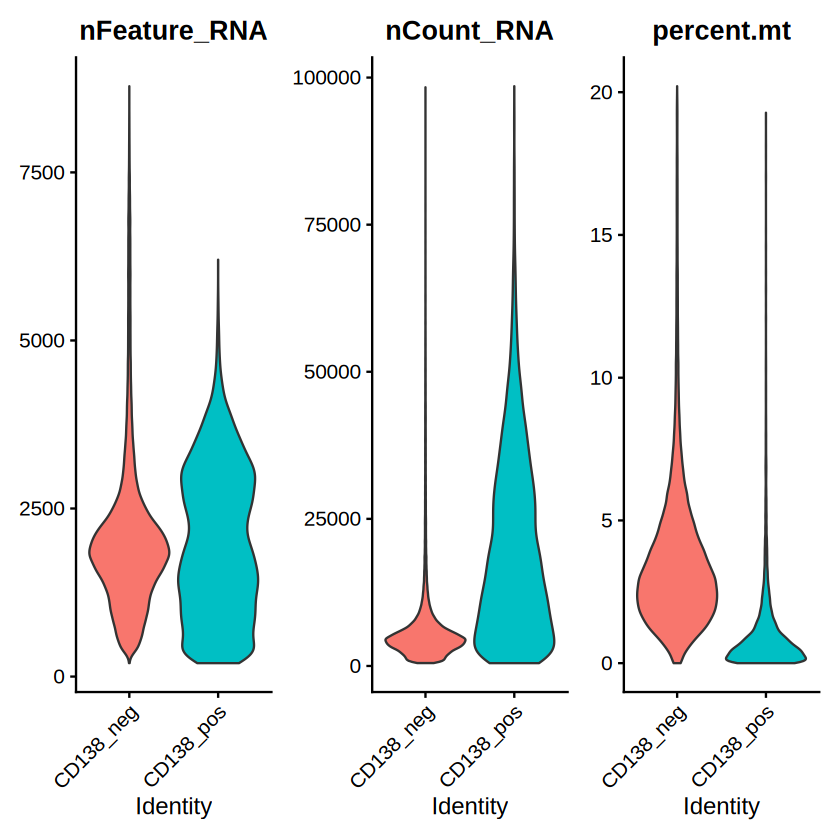

In [15]:
# ============================================================
# 11) Basic QC
# ============================================================

DefaultAssay(obj) <- "RNA"

obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^MT-")

message("QC summary:")
print(summary(obj@meta.data[, c("nCount_RNA", "nFeature_RNA", "percent.mt")]))

message("Cells by sample:")
print(table(obj$sample_id_raw, useNA = "ifany"))

message("Cells by condition and CD138 fraction:")
print(table(obj$condition_final, obj$CD138_fraction_final, useNA = "ifany"))

p_qc <- VlnPlot(
  obj,
  features = c("nFeature_RNA", "nCount_RNA", "percent.mt"),
  group.by = "CD138_fraction_final",
  pt.size = 0,
  ncol = 3
)

print(p_qc)

ggsave(
  filename = file.path(out_dir, "QC_violin_by_CD138_fraction_with_BRI.pdf"),
  plot = p_qc,
  width = 10,
  height = 4
)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


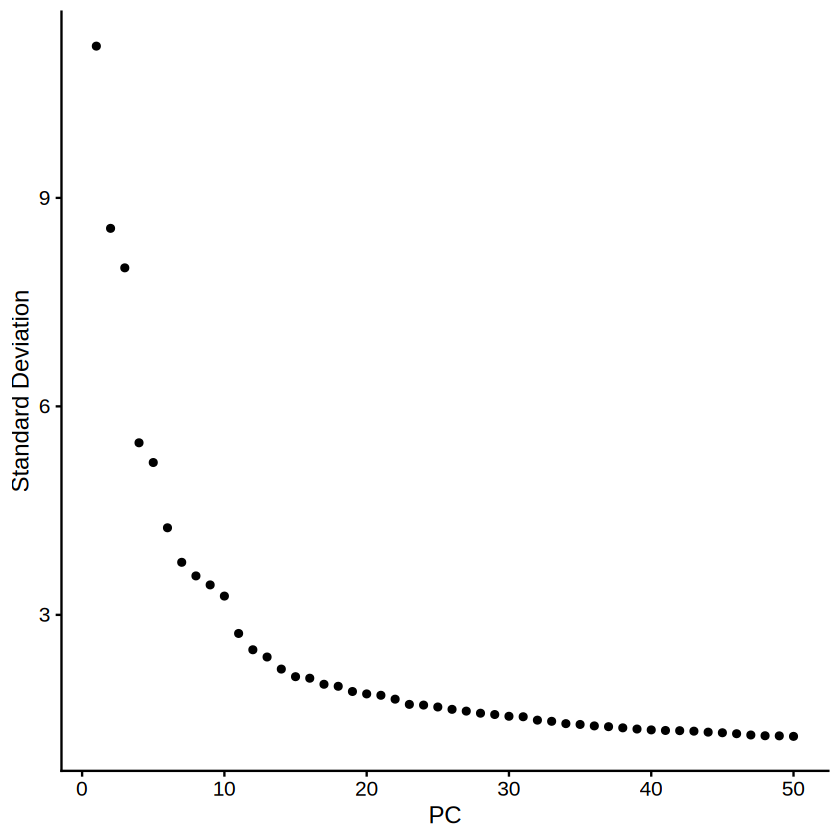

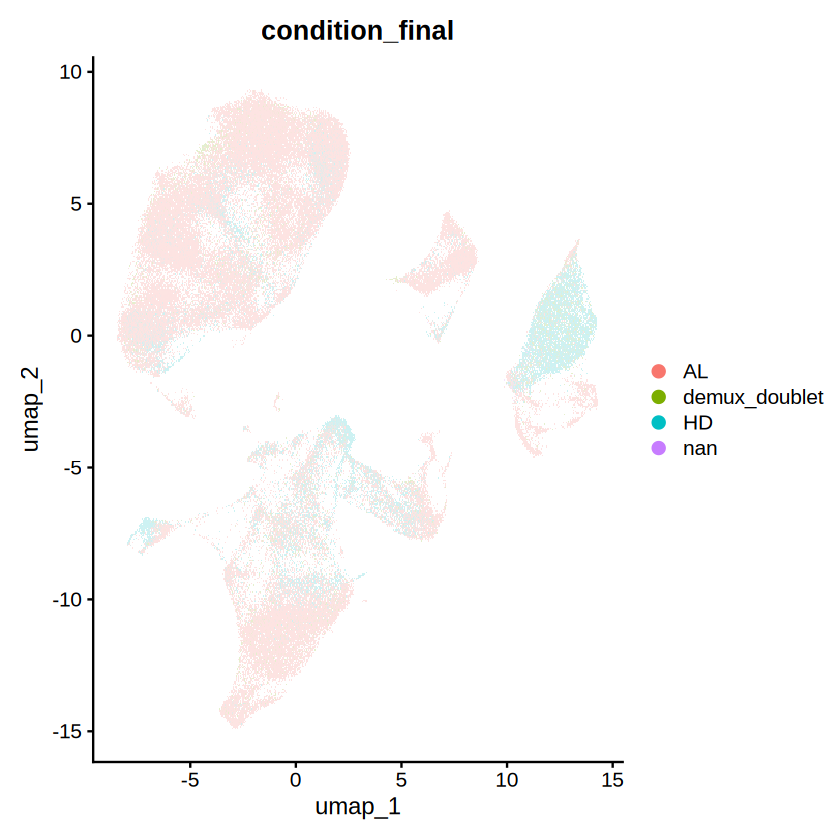

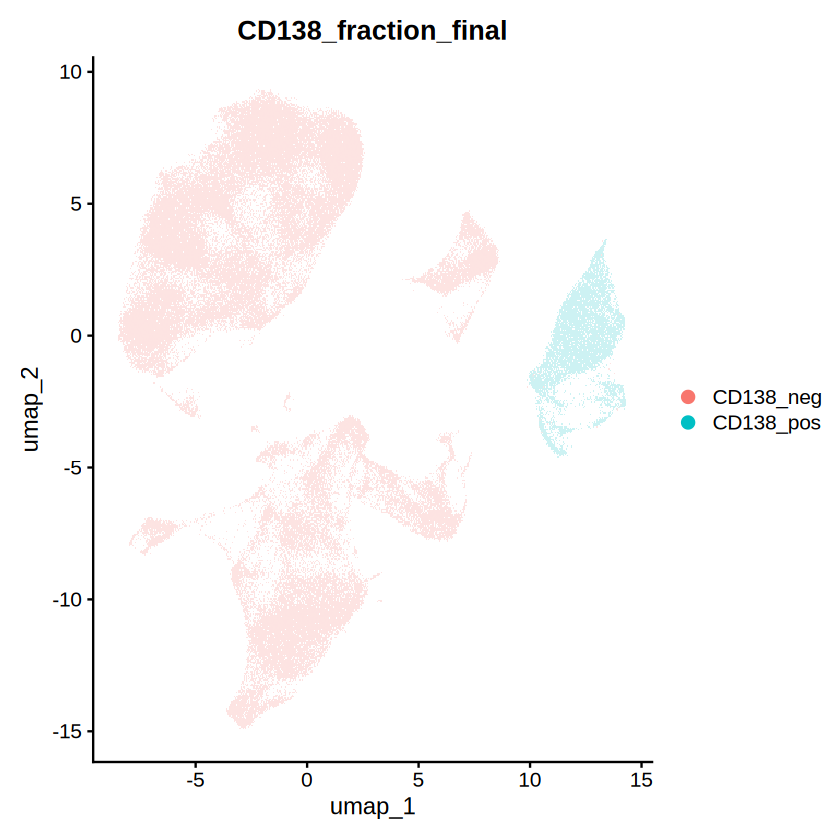

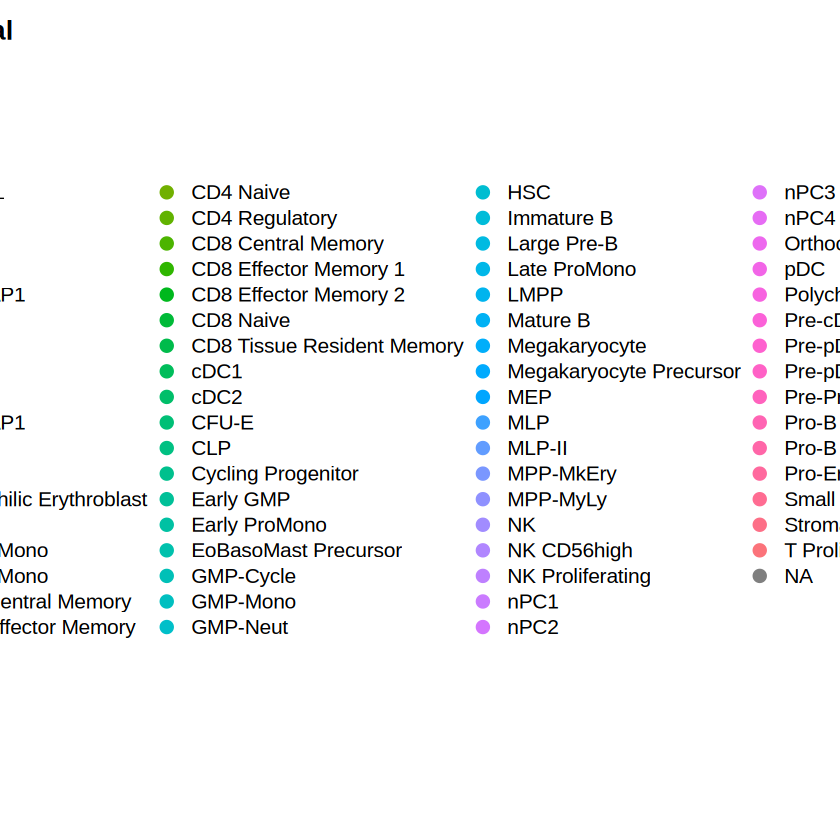

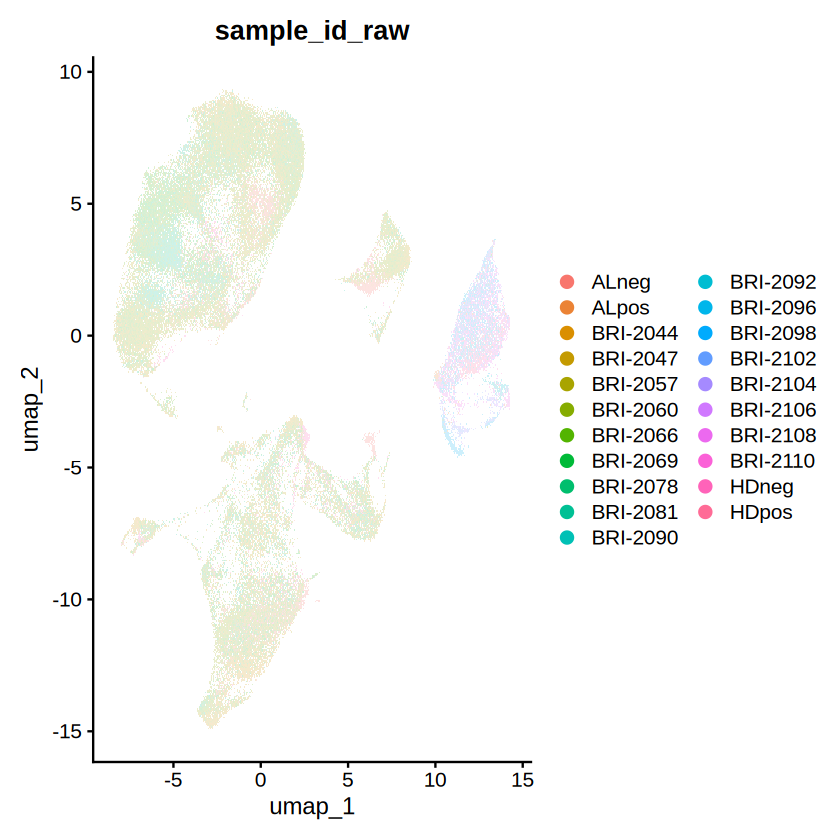

In [16]:
# ============================================================
# 13) Optional normalization / PCA / UMAP
# ============================================================

obj <- NormalizeData(obj, verbose = FALSE)
obj <- FindVariableFeatures(obj, selection.method = "vst", nfeatures = 3000, verbose = FALSE)
obj <- ScaleData(obj, features = VariableFeatures(obj), verbose = FALSE)
obj <- RunPCA(obj, features = VariableFeatures(obj), npcs = 50, verbose = FALSE)

print(ElbowPlot(obj, ndims = 50))

obj <- FindNeighbors(obj, dims = 1:30, verbose = FALSE)
obj <- FindClusters(obj, resolution = 0.5, verbose = FALSE)
obj <- RunUMAP(obj, dims = 1:30, verbose = FALSE)

p1 <- DimPlot(obj, reduction = "umap", group.by = "condition_final", pt.size = 0.2, raster = TRUE)
p2 <- DimPlot(obj, reduction = "umap", group.by = "CD138_fraction_final", pt.size = 0.2, raster = TRUE)
p3 <- DimPlot(obj, reduction = "umap", group.by = "cell_annotation_final", pt.size = 0.2, raster = TRUE)
p4 <- DimPlot(obj, reduction = "umap", group.by = "sample_id_raw", pt.size = 0.2, raster = TRUE)

print(p1)
print(p2)
print(p3)
print(p4)

ggsave(file.path(out_dir, "UMAP_condition_with_BRI.pdf"), p1, width = 6, height = 5)
ggsave(file.path(out_dir, "UMAP_CD138_fraction_with_BRI.pdf"), p2, width = 6, height = 5)
ggsave(file.path(out_dir, "UMAP_annotation_with_BRI.pdf"), p3, width = 8, height = 6)
ggsave(file.path(out_dir, "UMAP_sample_id_raw_with_BRI.pdf"), p4, width = 10, height = 6)

## 5. Sample metadata and clinical groups


In [17]:
# ============================================================
# 14) Visualize each metadata feature on UMAP
# ============================================================

umap_meta_dir <- file.path(out_dir, "UMAP_metadata_features_with_BRI")
dir.create(umap_meta_dir, showWarnings = FALSE, recursive = TRUE)

if (!"umap" %in% Reductions(obj)) {
  stop("UMAP reduction not found. Run Section 13 first.")
}

skip_cols <- c(
  "nCount_RNA", "nFeature_RNA",
  "cell_id_raw_counts", "barcode_core_from_counts",
  "meta_cell_id_metadata"
)

meta_cols <- setdiff(colnames(obj@meta.data), skip_cols)

meta_cols <- meta_cols[
  sapply(meta_cols, function(x) {
    v <- obj@meta.data[[x]]
    v <- v[!is.na(v)]
    length(unique(v)) > 1
  })
]

plot_umap_metadata <- function(obj, feature, out_dir, max_categories = 60) {
  v <- obj@meta.data[[feature]]
  n_unique <- length(unique(v[!is.na(v)]))
  safe_feature <- str_replace_all(feature, "[^A-Za-z0-9_\\-]", "_")

  if (is.numeric(v) || is.integer(v)) {
    p <- FeaturePlot(
      obj,
      features = feature,
      reduction = "umap",
      pt.size = 0.2,
      order = TRUE
    ) + ggtitle(feature)

    ggsave(
      filename = file.path(out_dir, paste0("UMAP_", safe_feature, "_continuous.pdf")),
      plot = p,
      width = 6,
      height = 5
    )
    return(p)
  }

  if (n_unique > max_categories) {
    message("Skipping ", feature, ": too many categories = ", n_unique)
    return(NULL)
  }

  obj[[feature]] <- factor(obj@meta.data[[feature]])

  p <- DimPlot(
    obj,
    reduction = "umap",
    group.by = feature,
    pt.size = 0.2,
    label = FALSE,
    raster = TRUE
  ) + ggtitle(paste0(feature, " (n=", n_unique, ")"))

  ggsave(
    filename = file.path(out_dir, paste0("UMAP_", safe_feature, "_categorical.pdf")),
    plot = p,
    width = ifelse(n_unique > 15, 9, 6),
    height = 5
  )

  p
}

umap_meta_plots <- list()

for (feature in meta_cols) {
  message("Plotting metadata feature: ", feature)
  umap_meta_plots[[feature]] <- plot_umap_metadata(
    obj = obj,
    feature = feature,
    out_dir = umap_meta_dir,
    max_categories = 60
  )
}

pdf(file.path(umap_meta_dir, "All_metadata_UMAPs_with_BRI.pdf"), width = 7, height = 5)
for (feature in meta_cols) {
  v <- obj@meta.data[[feature]]
  n_unique <- length(unique(v[!is.na(v)]))

  if (is.numeric(v) || is.integer(v)) {
    print(
      FeaturePlot(obj, features = feature, reduction = "umap", pt.size = 0.2, order = TRUE) +
        ggtitle(feature)
    )
  } else if (n_unique <= 60 && n_unique > 1) {
    print(
      DimPlot(obj, reduction = "umap", group.by = feature, pt.size = 0.2,
              label = FALSE, raster = TRUE) +
        ggtitle(paste0(feature, " (n=", n_unique, ")"))
    )
  }
}
dev.off()

message("Saved metadata UMAPs to: ", umap_meta_dir)

Plotting metadata feature: sample_id_raw

Plotting metadata feature: sample_id_from_cell_id

Plotting metadata feature: sample_id_for_matching

Plotting metadata feature: sample_group_inferred

Plotting metadata feature: disease_inferred

Plotting metadata feature: CD138_fraction_inferred

Plotting metadata feature: meta_library_name

Plotting metadata feature: donor_id_global

Plotting metadata feature: condition

Plotting metadata feature: PC_subset

Plotting metadata feature: projected_CellType

Plotting metadata feature: cell_annotation_from_metadata

Skipping cell_annotation_from_metadata: too many categories = 69

Plotting metadata feature: CD138_fraction

Plotting metadata feature: metadata_source_file

Plotting metadata feature: CD138_fraction_final

Plotting metadata feature: condition_final

Plotting metadata feature: cell_annotation_final

Skipping cell_annotation_final: too many categories = 69

Plotting metadata feature: percent.mt

Rasterizing points since number of point

pdf 
  2

Saved metadata UMAPs to: ./GSE292189_Seurat_assembly/UMAP_metadata_features_with_BRI



In [18]:
# ============================================================
# 15) Save assembled object and metadata
# ============================================================

saveRDS(obj, out_rds)
message("Saved Seurat object to: ", out_rds)

fwrite(
  obj@meta.data %>%
    rownames_to_column("cell"),
  file = out_meta_csv
)
message("Saved assembled cell metadata to: ", out_meta_csv)

obj

Saved Seurat object to: ./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_seurat.rds

Saved assembled cell metadata to: ./GSE292189_Seurat_assembly/GSE292189_cell_metadata_after_assembly_with_BRI.csv.gz



An object of class Seurat 
25111 features across 104871 samples within 1 assay 
Active assay: RNA (25111 features, 3000 variable features)
 43 layers present: counts.1, counts.2, counts.3, counts.4, counts.5, counts.6, counts.7, counts.8, counts.9, counts.10, counts.11, counts.12, counts.13, counts.14, counts.15, counts.16, counts.17, counts.18, counts.19, counts.20, counts.21, data.1, data.2, data.3, data.4, data.5, data.6, data.7, data.8, data.9, data.10, data.11, data.12, data.13, data.14, data.15, data.16, data.17, data.18, data.19, data.20, data.21, scale.data
 2 dimensional reductions calculated: pca, umap

In [19]:
# ============================================================
# 16) Final checks
# ============================================================

message("Raw samples absent from metadata:")
print(setdiff(unique(obj$sample_id_for_matching), unique(meta_all$sample_id_for_matching)))

message("Metadata samples absent from raw object:")
print(setdiff(unique(meta_all$sample_id_for_matching), unique(obj$sample_id_for_matching)))

message("Unmatched cells:")
print(sum(is.na(obj$condition)))

message("Unmatched cells by sample:")
print(
  obj@meta.data %>%
    rownames_to_column("cell") %>%
    filter(is.na(condition)) %>%
    count(sample_id_raw, sort = TRUE)
)

message("Matched cells by sample:")
print(
  obj@meta.data %>%
    rownames_to_column("cell") %>%
    filter(!is.na(condition)) %>%
    count(sample_id_raw, condition, CD138_fraction, sort = TRUE)
)

Raw samples absent from metadata:



character(0)


Metadata samples absent from raw object:



character(0)


Unmatched cells:



[1] 0


Unmatched cells by sample:



[1] sample_id_raw n            
<0 rows> (or 0-length row.names)


Matched cells by sample:



   sample_id_raw     condition CD138_fraction     n
1       BRI-2057            AL      CD138_neg 14222
2       BRI-2060            AL      CD138_neg 12724
3       BRI-2081            AL      CD138_neg 10170
4       BRI-2066            AL      CD138_neg  8943
5       BRI-2044            AL      CD138_neg  8611
6       BRI-2047            AL      CD138_neg  8302
7       BRI-2069            AL      CD138_neg  8269
8          ALneg            AL      CD138_neg  5689
9       BRI-2044            HD      CD138_neg  2564
10      BRI-2047            HD      CD138_neg  2442
11      BRI-2078            AL      CD138_neg  2390
12         HDneg            HD      CD138_neg  2158
13      BRI-2066            HD      CD138_neg  1669
14      BRI-2069            HD      CD138_neg  1501
15      BRI-2108            HD      CD138_pos  1442
16         HDpos            HD      CD138_pos  1365
17      BRI-2110            HD      CD138_pos  1020
18      BRI-2057            HD      CD138_neg   885
19      BRI-

In [20]:
# ============================================================
# Add BCR AIRR clonotype metadata to Seurat object
# ============================================================

suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(stringr)
  library(tibble)
  library(purrr)
})

# ------------------------------------------------------------
# 1) Locate BCR AIRR files
# ------------------------------------------------------------

bcr_files <- list.files(
  extract_dir,
  recursive = TRUE,
  full.names = TRUE,
  pattern = "bcr.*chains\\.airr\\.txt\\.gz$"
)

message("Detected BCR AIRR files: ", length(bcr_files))
print(basename(bcr_files))

if (length(bcr_files) == 0) {
  stop("No BCR AIRR files detected.")
}

Detected BCR AIRR files: 21



 [1] "GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz"
 [2] "GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz"
 [3] "GSM8852203_HDpos_bcr_bcr_chains.airr.txt.gz"
 [4] "GSM8852205_ALpos_bcr_bcr_chains.airr.txt.gz"
 [5] "GSM8852208_BRI-2046_bcr_chains.airr.txt.gz" 
 [6] "GSM8852211_BRI-2049_bcr_chains.airr.txt.gz" 
 [7] "GSM8852214_BRI-2059_bcr_chains.airr.txt.gz" 
 [8] "GSM8852217_BRI-2062_bcr_chains.airr.txt.gz" 
 [9] "GSM8852220_BRI-2068_bcr_chains.airr.txt.gz" 
[10] "GSM8852223_BRI-2071_bcr_chains.airr.txt.gz" 
[11] "GSM8852226_BRI-2080_bcr_chains.airr.txt.gz" 
[12] "GSM8852229_BRI-2083_bcr_chains.airr.txt.gz" 
[13] "GSM8852231_BRI-2091_bcr_chains.airr.txt.gz" 
[14] "GSM8852233_BRI-2093_bcr_chains.airr.txt.gz" 
[15] "GSM8852235_BRI-2097_bcr_chains.airr.txt.gz" 
[16] "GSM8852237_BRI-2099_bcr_chains.airr.txt.gz" 
[17] "GSM8852239_BRI-2103_bcr_chains.airr.txt.gz" 
[18] "GSM8852241_BRI-2105_bcr_chains.airr.txt.gz" 
[19] "GSM8852243_BRI-2107_bcr_chains.airr.txt.gz" 
[20] "GSM8852245_BRI-2109_bcr_c

In [21]:
# ------------------------------------------------------------
# 2) Helper functions
# ------------------------------------------------------------

normalize_library_to_sample_id <- function(x) {
  x <- as.character(x)
  dplyr::case_when(
    x == "HDpos_gex" ~ "HDpos",
    x == "HDneg_gex" ~ "HDneg",
    x == "ALpos_gex" ~ "ALpos",
    x == "ALneg_gex" ~ "ALneg",
    TRUE ~ x
  )
}

get_sample_prefix <- function(cell_ids) {
  cell_ids <- as.character(cell_ids)
  
  dplyr::case_when(
    str_detect(cell_ids, "^HDpos-") ~ "HDpos",
    str_detect(cell_ids, "^HDneg-") ~ "HDneg",
    str_detect(cell_ids, "^ALpos-") ~ "ALpos",
    str_detect(cell_ids, "^ALneg-") ~ "ALneg",
    str_detect(cell_ids, "^BRI-[0-9]+-") ~ str_extract(cell_ids, "^BRI-[0-9]+"),
    TRUE ~ NA_character_
  )
}

get_barcode_core_safe <- function(cell_ids, sample_id = NULL) {
  cell_ids <- as.character(cell_ids)
  
  if (!is.null(sample_id)) {
    sample_id <- as.character(sample_id)
    
    out <- mapply(
      function(cid, sid) {
        if (is.na(cid) || is.na(sid) || sid == "") return(cid)
        
        prefix <- paste0(sid, "-")
        
        if (startsWith(cid, prefix)) {
          sub(prefix, "", cid, fixed = TRUE)
        } else {
          cid
        }
      },
      cell_ids,
      sample_id,
      USE.NAMES = FALSE
    )
  } else {
    out <- cell_ids
    
    out <- ifelse(startsWith(out, "HDpos-"), sub("HDpos-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "HDneg-"), sub("HDneg-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "ALpos-"), sub("ALpos-", "", out, fixed = TRUE), out)
    out <- ifelse(startsWith(out, "ALneg-"), sub("ALneg-", "", out, fixed = TRUE), out)
    
    bri_prefix <- str_extract(out, "^BRI-[0-9]+-")
    out <- ifelse(
      !is.na(bri_prefix),
      substring(out, nchar(bri_prefix) + 1),
      out
    )
  }
  
  out <- str_replace(out, "-[0-9]+$", "")
  out
}

detect_first_present_col <- function(df, candidates) {
  hit <- intersect(candidates, colnames(df))
  if (length(hit) == 0) return(NA_character_)
  hit[1]
}

## 6. Clonotype assignment and repertoire analysis


In [22]:
# ------------------------------------------------------------
# 3) Read one AIRR BCR file robustly
# ------------------------------------------------------------

read_bcr_airr_one <- function(path) {
  message("Reading BCR AIRR: ", basename(path))
  
  x <- fread(path)
  x <- as.data.frame(x)
  
  message("Columns:")
  print(colnames(x))
  
  # Common AIRR / dandelion / scirpy-style columns
  cell_col <- detect_first_present_col(
    x,
    c(
      "cell_id", "barcode", "cell", "contig_id",
      "sequence_id", "sequence_id_10x", "Cell"
    )
  )
  
  if (is.na(cell_col)) {
    stop(
      "Could not detect cell/barcode column in: ", basename(path),
      "\nAvailable columns: ", paste(colnames(x), collapse = ", ")
    )
  }
  
  clone_col <- detect_first_present_col(
    x,
    c(
      "clone_id", "clonotype_id", "clone", "clonotype",
      "raw_clonotype_id", "exact_subclonotype_id"
    )
  )
  
  locus_col <- detect_first_present_col(
    x,
    c("locus", "chain", "receptor_type")
  )
  
  productive_col <- detect_first_present_col(
    x,
    c("productive", "is_cell", "high_confidence")
  )
  
  cdr3_col <- detect_first_present_col(
    x,
    c("junction_aa", "cdr3", "cdr3_aa", "junction")
  )
  
  v_col <- detect_first_present_col(
    x,
    c("v_call", "v_gene", "v_gene_call")
  )
  
  d_col <- detect_first_present_col(
    x,
    c("d_call", "d_gene", "d_gene_call")
  )
  
  j_col <- detect_first_present_col(
    x,
    c("j_call", "j_gene", "j_gene_call")
  )
  
  c_col <- detect_first_present_col(
    x,
    c("c_call", "c_gene", "c_gene_call", "constant")
  )
  
  umi_col <- detect_first_present_col(
    x,
    c("umi_count", "umis", "duplicate_count", "consensus_count", "read_count")
  )
  
  # File-level sample ID from filename.
  # For grouped files, this gives HDneg / ALneg / HDpos / ALpos.
  # For BRI BCR files, this gives BRI-2046 / BRI-2049 etc.,
  # which may not be identical to the RNA sample ID, so we do not rely on it alone.
  file_sample <- basename(path) %>%
    str_replace("\\.txt\\.gz$", "") %>%
    str_replace("_bcr_bcr_chains\\.airr$", "") %>%
    str_replace("_bcr_chains\\.airr$", "") %>%
    str_replace("^GSM[0-9]+_", "")
  
  out <- tibble(
    bcr_file = basename(path),
    bcr_file_sample = file_sample,
    bcr_cell_id_raw = as.character(x[[cell_col]]),
    bcr_clone_id_raw = if (!is.na(clone_col)) as.character(x[[clone_col]]) else NA_character_,
    bcr_locus = if (!is.na(locus_col)) as.character(x[[locus_col]]) else NA_character_,
    bcr_productive_raw = if (!is.na(productive_col)) as.character(x[[productive_col]]) else NA_character_,
    bcr_cdr3_aa = if (!is.na(cdr3_col)) as.character(x[[cdr3_col]]) else NA_character_,
    bcr_v_call = if (!is.na(v_col)) as.character(x[[v_col]]) else NA_character_,
    bcr_d_call = if (!is.na(d_col)) as.character(x[[d_col]]) else NA_character_,
    bcr_j_call = if (!is.na(j_col)) as.character(x[[j_col]]) else NA_character_,
    bcr_c_call = if (!is.na(c_col)) as.character(x[[c_col]]) else NA_character_,
    bcr_umi_count = if (!is.na(umi_col)) suppressWarnings(as.numeric(x[[umi_col]])) else NA_real_
  )
  
  # Infer sample from the AIRR cell ID if it has a prefix.
  out$bcr_sample_from_cell_id <- get_sample_prefix(out$bcr_cell_id_raw)
  
  # For grouped files, if AIRR cell IDs are bare barcodes, use the file sample.
  # For BRI files, prefer sample encoded in the cell ID if available.
  out$bcr_sample_id_for_matching <- ifelse(
    !is.na(out$bcr_sample_from_cell_id),
    out$bcr_sample_from_cell_id,
    normalize_library_to_sample_id(out$bcr_file_sample)
  )
  
  out$bcr_barcode_core <- get_barcode_core_safe(
    cell_ids = out$bcr_cell_id_raw,
    sample_id = out$bcr_sample_id_for_matching
  )
  
  out
}

In [23]:
# ------------------------------------------------------------
# 4) Read and combine all BCR AIRR files
# ------------------------------------------------------------

bcr_long <- map_dfr(bcr_files, read_bcr_airr_one)

message("Combined BCR AIRR rows: ", nrow(bcr_long))
message("BCR samples inferred:")
print(table(bcr_long$bcr_sample_id_for_matching, useNA = "ifany"))

message("BCR loci:")
print(table(bcr_long$bcr_locus, useNA = "ifany"))

head(bcr_long)

Reading BCR AIRR: GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz

Columns:



 [1] "sequence_id"        "sequence"           "rev_comp"          
 [4] "productive"         "v_call"             "d_call"            
 [7] "j_call"             "sequence_alignment" "germline_alignment"
[10] "junction"           "junction_aa"        "v_cigar"           
[13] "d_cigar"            "j_cigar"            "cell_id"           
[16] "c_call"             "cdr1"               "cdr1_aa"           
[19] "cdr2"               "cdr2_aa"            "cdr3"              
[22] "cdr3_aa"            "consensus_count"    "duplicate_count"   
[25] "fwr1"               "fwr1_aa"            "fwr2"              
[28] "fwr2_aa"            "fwr3"               "fwr3_aa"           
[31] "fwr4"               "fwr4_aa"            "locus"             
[34] "library_name"       "sample_fraction"    "receptor_type"     
[37] "receptor_subtype"   "chain_pairing"      "high_confidence"   
[40] "is_cell"           


Reading BCR AIRR: GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz

Columns:



 [1] "sequence_id"        "sequence"           "rev_comp"          
 [4] "productive"         "v_call"             "d_call"            
 [7] "j_call"             "sequence_alignment" "germline_alignment"
[10] "junction"           "junction_aa"        "v_cigar"           
[13] "d_cigar"            "j_cigar"            "cell_id"           
[16] "c_call"             "cdr1"               "cdr1_aa"           
[19] "cdr2"               "cdr2_aa"            "cdr3"              
[22] "cdr3_aa"            "consensus_count"    "duplicate_count"   
[25] "fwr1"               "fwr1_aa"            "fwr2"              
[28] "fwr2_aa"            "fwr3"               "fwr3_aa"           
[31] "fwr4"               "fwr4_aa"            "locus"             
[34] "library_name"       "sample_fraction"    "receptor_type"     
[37] "receptor_subtype"   "chain_pairing"      "high_confidence"   
[40] "is_cell"           


Reading BCR AIRR: GSM8852203_HDpos_bcr_bcr_chains.airr.txt.gz

Columns:



...

Combined BCR AIRR rows: 37377

BCR samples inferred:




   ALneg    ALpos BRI-2044 BRI-2047 BRI-2057 BRI-2060 BRI-2066 BRI-2069 
    2456      633     1750     1671     2920     2695      829      811 
BRI-2078 BRI-2081 BRI-2090 BRI-2092 BRI-2096 BRI-2098 BRI-2102 BRI-2104 
      62      585      549     2358     3791     3896     1193     1203 
BRI-2106 BRI-2108 BRI-2110    HDneg    HDpos 
    1837     1594     3764      162     2618 


BCR loci:




        IGH   IGK   IGL 
 2077 15996  9795  9509 


bcr_file,bcr_file_sample,bcr_cell_id_raw,bcr_clone_id_raw,bcr_locus,bcr_productive_raw,bcr_cdr3_aa,bcr_v_call,bcr_d_call,bcr_j_call,bcr_c_call,bcr_umi_count,bcr_sample_from_cell_id,bcr_sample_id_for_matching,bcr_barcode_core
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AAAGCAATCAGGCAAG,NA,IGK,T,CQQYYSPPWTF,IGKV4-1,,IGKJ1,IGKC,5,HDneg,HDneg,AAAGCAATCAGGCAAG
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AAAGCAATCAGGCAAG,NA,IGH,T,CATRSPLRPLDPASYFDYW,IGHV1-24,,IGHJ4,IGHA1,1,HDneg,HDneg,AAAGCAATCAGGCAAG
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AACACGTAGGTGGGTT,NA,IGK,T,CQQYGSSPTF,IGKV3-20,,IGKJ4,IGKC,32,HDneg,HDneg,AACACGTAGGTGGGTT
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AACACGTAGGTGGGTT,NA,IGH,T,CACRPTDGATVAKPPPPAGYW,IGHV3-11,,IGHJ4,IGHM,27,HDneg,HDneg,AACACGTAGGTGGGTT
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AAGACCTGTCGCTTCT,NA,IGH,T,CATWYGVGADYFDYW,IGHV3-43,,IGHJ4,IGHM,38,HDneg,HDneg,AAGACCTGTCGCTTCT
GSM8852198_HDneg_bcr_bcr_chains.airr.txt.gz,HDneg,HDneg-AAGACCTGTCGCTTCT,NA,IGK,T,CQQRSNWPPGGTF,IGKV3-11,,IGKJ1,IGKC,10,HDneg,HDneg,AAGACCTGTCGCTTCT


In [24]:
# ------------------------------------------------------------
# 5) Optional: filter to productive BCR chains if productive column exists
# ------------------------------------------------------------

bcr_long <- bcr_long %>%
  mutate(
    bcr_productive = case_when(
      is.na(bcr_productive_raw) ~ NA,
      tolower(bcr_productive_raw) %in% c("true", "t", "1", "yes") ~ TRUE,
      tolower(bcr_productive_raw) %in% c("false", "f", "0", "no") ~ FALSE,
      TRUE ~ NA
    )
  )

# Keep productive if the productive field exists.
# If productive is entirely NA, keep all rows.
if (any(!is.na(bcr_long$bcr_productive))) {
  bcr_long_use <- bcr_long %>%
    filter(is.na(bcr_productive) | bcr_productive)
} else {
  bcr_long_use <- bcr_long
}

message("BCR rows after productive filtering: ", nrow(bcr_long_use))

BCR rows after productive filtering: 28809



## 7. Summarize BCR clonotype information per cell


In [25]:
# ------------------------------------------------------------
# 6) Summarize BCR clonotype information per cell
# ------------------------------------------------------------

collapse_unique <- function(x, sep = ";") {
  x <- unique(na.omit(as.character(x)))
  x <- x[x != ""]
  if (length(x) == 0) return(NA_character_)
  paste(x, collapse = sep)
}

bcr_cell_meta <- bcr_long_use %>%
  group_by(
    bcr_sample_id_for_matching,
    bcr_barcode_core
  ) %>%
  summarise(
    has_bcr = TRUE,
    n_bcr_chains = n(),
    n_bcr_loci = n_distinct(bcr_locus[!is.na(bcr_locus) & bcr_locus != ""]),
    bcr_loci = collapse_unique(bcr_locus),
    
    bcr_clone_id = collapse_unique(bcr_clone_id_raw),
    n_bcr_clone_ids = n_distinct(bcr_clone_id_raw[!is.na(bcr_clone_id_raw) & bcr_clone_id_raw != ""]),
    
    bcr_cdr3_aa = collapse_unique(bcr_cdr3_aa),
    bcr_v_call = collapse_unique(bcr_v_call),
    bcr_d_call = collapse_unique(bcr_d_call),
    bcr_j_call = collapse_unique(bcr_j_call),
    bcr_c_call = collapse_unique(bcr_c_call),
    
    bcr_total_umi = if (all(is.na(bcr_umi_count))) NA_real_ else sum(bcr_umi_count, na.rm = TRUE),
    bcr_max_umi = if (all(is.na(bcr_umi_count))) NA_real_ else max(bcr_umi_count, na.rm = TRUE),
    
    bcr_files = collapse_unique(bcr_file),
    .groups = "drop"
  ) %>%
  mutate(
    bcr_has_heavy = str_detect(paste0(bcr_loci, collapse = ";"), "IGH"),
    bcr_has_light = str_detect(paste0(bcr_loci, collapse = ";"), "IGK|IGL")
  )

message("BCR cell-level metadata rows: ", nrow(bcr_cell_meta))
head(bcr_cell_meta)

BCR cell-level metadata rows: 14740



bcr_sample_id_for_matching,bcr_barcode_core,has_bcr,n_bcr_chains,n_bcr_loci,bcr_loci,bcr_clone_id,n_bcr_clone_ids,bcr_cdr3_aa,bcr_v_call,bcr_d_call,bcr_j_call,bcr_c_call,bcr_total_umi,bcr_max_umi,bcr_files,bcr_has_heavy,bcr_has_light
<chr>,<chr>,<lgl>,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
ALneg,AAACCTGAGGTGGGTT,TRUE,2,2,IGH;IGK,NA,0,CASSPLDFITMIVVEYDYW;CQQYYNWPLTF,IGHV4-39;IGKV3-15,IGHD3-22,IGHJ4;IGKJ4,IGHM;IGKC,7,5,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE
ALneg,AAACCTGCATCCGGGT,TRUE,2,2,IGH;IGK,NA,0,CAGKAGDSEDYYYYYMDVW;CQQYYSYPPTF,IGHV3-21;IGKV1-8,NA,IGHJ6;IGKJ1,IGHM;IGKC,55,39,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE
ALneg,AAACCTGTCACCTTAT,TRUE,2,2,IGL;IGH,NA,0,CAAWDDRLNGWVF;CARESGGYCSSTSCPNYYYYYYMDVW,IGLV1-36;IGHV3-48,IGHD2-2,IGLJ3;IGHJ6,IGLC2;IGHM,35,18,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE
ALneg,AAACCTGTCGAACGGA,TRUE,2,2,IGH;IGK,NA,0,CARGEGYCSSTSCYTWIDYW;CQQYNSYPRTF,IGHV4-4;IGKV1-16,IGHD2-2,IGHJ4;IGKJ1,IGHM;IGKC,40,23,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE
ALneg,AAACGGGAGGGTGTTG,TRUE,2,2,IGH;IGL,NA,0,CARAPHPTMVRGYYMDVW;CQAWDSSTVVF,IGHV1-8;IGLV3-1,NA,IGHJ6;IGLJ2,IGHM;IGLC2,53,40,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE
ALneg,AAACGGGCAGGACGTA,TRUE,1,1,IGK,NA,0,CMQSIQLRTF,IGKV2D-29,NA,IGKJ1,IGKC,4,4,GSM8852201_ALneg_bcr_bcr_chains.airr.txt.gz,TRUE,TRUE


In [26]:
# ------------------------------------------------------------
# 7) Join BCR clonotype metadata to Seurat object
# ------------------------------------------------------------

# Build Seurat-side join key.
# This assumes your object already has:
#   sample_id_for_matching
#   barcode_core_from_counts
# from the patched assembly notebook.
#
# If not, recreate them from existing metadata.

if (!"sample_id_for_matching" %in% colnames(obj@meta.data)) {
  obj$sample_id_for_matching <- obj$sample_id_raw
}

if (!"barcode_core_from_counts" %in% colnames(obj@meta.data)) {
  if (!"cell_id_raw_counts" %in% colnames(obj@meta.data)) {
    stop("Need either barcode_core_from_counts or cell_id_raw_counts in obj@meta.data.")
  }
  
  obj$barcode_core_from_counts <- get_barcode_core_safe(
    cell_ids = obj$cell_id_raw_counts,
    sample_id = obj$sample_id_for_matching
  )
}

obj_key <- obj@meta.data %>%
  rownames_to_column("cell") %>%
  transmute(
    cell,
    sample_id_for_matching = as.character(sample_id_for_matching),
    barcode_core_from_counts = as.character(barcode_core_from_counts)
  )

bcr_joined <- obj_key %>%
  left_join(
    bcr_cell_meta,
    by = c(
      "sample_id_for_matching" = "bcr_sample_id_for_matching",
      "barcode_core_from_counts" = "bcr_barcode_core"
    )
  )

message("BCR join summary:")
print(table(!is.na(bcr_joined$has_bcr), useNA = "ifany"))

message("BCR-positive cells by sample:")
print(
  bcr_joined %>%
    mutate(has_bcr = ifelse(is.na(has_bcr), FALSE, has_bcr)) %>%
    count(sample_id_for_matching, has_bcr, sort = TRUE)
)

# Add to object
bcr_meta_to_add <- bcr_joined %>%
  select(
    cell,
    has_bcr,
    n_bcr_chains,
    n_bcr_loci,
    bcr_loci,
    bcr_clone_id,
    n_bcr_clone_ids,
    bcr_cdr3_aa,
    bcr_v_call,
    bcr_d_call,
    bcr_j_call,
    bcr_c_call,
    bcr_total_umi,
    bcr_max_umi,
    bcr_has_heavy,
    bcr_has_light,
    bcr_files
  ) %>%
  as.data.frame()

rownames(bcr_meta_to_add) <- bcr_meta_to_add$cell
bcr_meta_to_add$cell <- NULL

# Fill defaults for BCR-negative cells
bcr_meta_to_add$has_bcr[is.na(bcr_meta_to_add$has_bcr)] <- FALSE
bcr_meta_to_add$n_bcr_chains[is.na(bcr_meta_to_add$n_bcr_chains)] <- 0
bcr_meta_to_add$n_bcr_loci[is.na(bcr_meta_to_add$n_bcr_loci)] <- 0
bcr_meta_to_add$n_bcr_clone_ids[is.na(bcr_meta_to_add$n_bcr_clone_ids)] <- 0
bcr_meta_to_add$bcr_has_heavy[is.na(bcr_meta_to_add$bcr_has_heavy)] <- FALSE
bcr_meta_to_add$bcr_has_light[is.na(bcr_meta_to_add$bcr_has_light)] <- FALSE

obj <- AddMetaData(obj, metadata = bcr_meta_to_add)

message("Added BCR metadata columns:")
print(colnames(bcr_meta_to_add))

message("Final BCR-positive cells:")
print(table(obj$has_bcr, useNA = "ifany"))

BCR join summary:




FALSE  TRUE 
90325 14546 


BCR-positive cells by sample:



   sample_id_for_matching has_bcr     n
1                BRI-2057   FALSE 14570
2                BRI-2060   FALSE 12044
3                BRI-2044   FALSE 10921
4                BRI-2066   FALSE 10757
5                BRI-2047   FALSE 10605
6                BRI-2081   FALSE 10478
7                BRI-2069   FALSE  9876
8                   ALneg   FALSE  4468
9                BRI-2078   FALSE  2365
10                  HDneg   FALSE  2071
11               BRI-2108   FALSE  1541
12               BRI-2110    TRUE  1419
13               BRI-2098    TRUE  1399
14               BRI-2096    TRUE  1282
15                  HDpos    TRUE  1245
16                  ALneg    TRUE  1221
17               BRI-2057    TRUE  1183
18               BRI-2060    TRUE  1099
19               BRI-2092    TRUE   776
20               BRI-2044    TRUE   658
21               BRI-2108    TRUE   656
22               BRI-2106    TRUE   654
23               BRI-2047    TRUE   635
24               BRI-2102    TRUE   448


Added BCR metadata columns:



 [1] "has_bcr"         "n_bcr_chains"    "n_bcr_loci"      "bcr_loci"       
 [5] "bcr_clone_id"    "n_bcr_clone_ids" "bcr_cdr3_aa"     "bcr_v_call"     
 [9] "bcr_d_call"      "bcr_j_call"      "bcr_c_call"      "bcr_total_umi"  
[13] "bcr_max_umi"     "bcr_has_heavy"   "bcr_has_light"   "bcr_files"      


Final BCR-positive cells:




FALSE  TRUE 
90325 14546 


Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



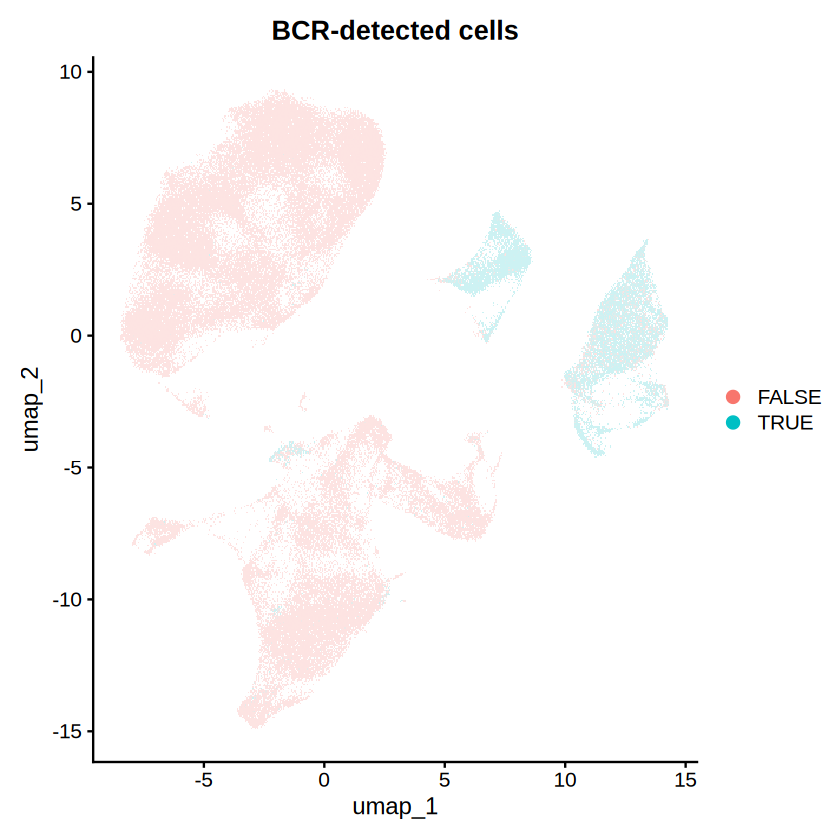

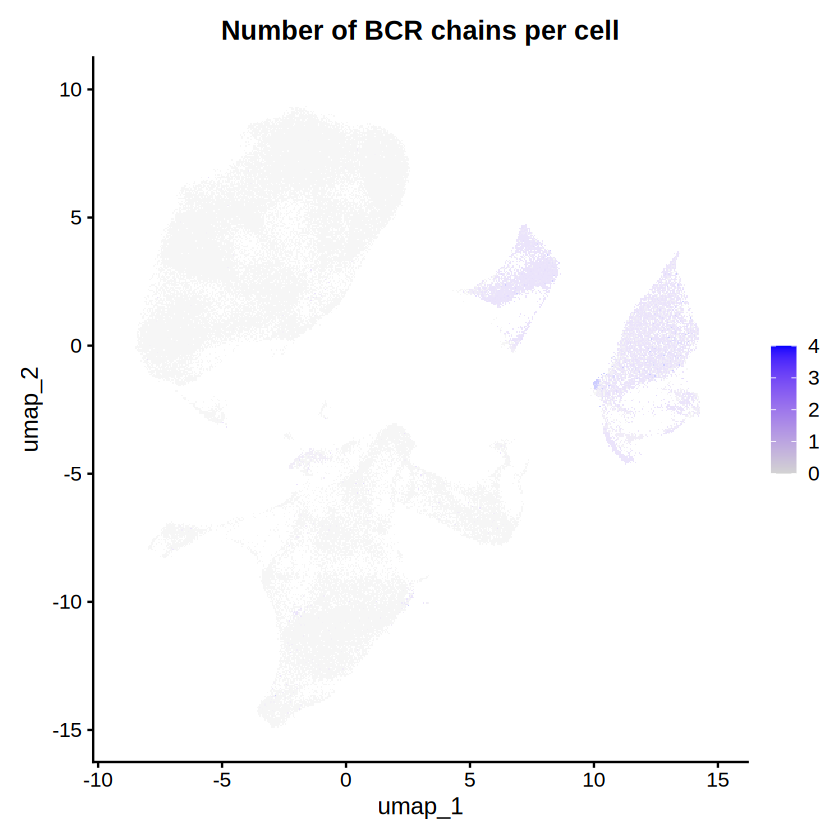

In [27]:
# ============================================================
# UMAP visualization of BCR metadata
# ============================================================

if (!"umap" %in% Reductions(obj)) {
  stop("UMAP not found. Run RunUMAP first.")
}

DimPlot(
  obj,
  reduction = "umap",
  group.by = "has_bcr",
  pt.size = 0.2,
  raster = TRUE
) +
  ggtitle("BCR-detected cells")

FeaturePlot(
  obj,
  features = "n_bcr_chains",
  reduction = "umap",
  pt.size = 0.2,
  order = TRUE
) +
  ggtitle("Number of BCR chains per cell")

In [28]:
# ============================================================
# Save object with BCR metadata
# ============================================================

out_rds_bcr <- file.path(out_dir, "GSE292189_assembled_with_BRI_and_BCR_clonotype.rds")
saveRDS(obj, out_rds_bcr)

message("Saved object with BCR clonotype metadata to:")
message(out_rds_bcr)

Saved object with BCR clonotype metadata to:

./GSE292189_Seurat_assembly/GSE292189_assembled_with_BRI_and_BCR_clonotype.rds

